In [48]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
import xarray as xr
import shutil
import matplotlib.pyplot as plt

import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

from scipy.optimize import curve_fit

In [2]:
shapefile_path =  Path.home() / "BEP-beau/BEP/code/CatchmentArea" / "CatchmentArea_4326.shp"
experiment_start_date = "1970-01-01T00:00:00Z"
experiment_end_date = "2014-12-31T00:00:00Z"
forcing_path_CMIP = Path.home() / "BEP-beau/BEP/code/CatchmentArea" / "CMIP6_"  
forcing_path_CMIP.mkdir(exist_ok=True)

In [3]:
cmip_historical =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-HR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical",)


historical_CMIP_location = forcing_path_CMIP / "historical" / "work" / "diagnostic" / "script"
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location)

In [4]:
cmip_historical_EC =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'EC-Earth3',
   "ensemble": 'r1i1p1f1',
   'grid': 'gr'
}

#CMIP_forcing_EC = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical_EC,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical_EC",)


historical_CMIP_location_EC = forcing_path_CMIP / "historical_EC" / "work" / "diagnostic" / "script"
historical_CMIP_forcing_EC = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location_EC)

In [5]:
cmip_historical2 =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-LR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical2,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical2",)


historical_CMIP_location2 = forcing_path_CMIP / "historical2" / "work" / "diagnostic" / "script"
historical_CMIP_forcing2 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location2)

In [6]:
print(historical_CMIP_forcing2)

LumpedMakkinkForcing(
    start_time='1970-01-01T00:00:00Z',
    end_time='2014-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/CMIP6_/historical2/work/diagnostic/script'),
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/CMIP6_/historical2/work/diagnostic/script/Catchment
Area_4326.shp'),
    filenames={
        'pr': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_pr_gn_1970-2014.nc',
        'tas': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_tas_gn_1970-2014.nc',
        'rsds': 'CMIP6_MPI-ESM1-2-LR_day_historical_r1i1p1f1_rsds_gn_1970-2014.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [7]:
pr = xr.open_dataset(historical_CMIP_forcing['pr'])
tas = xr.open_dataset(historical_CMIP_forcing['tas'])
rsds = xr.open_dataset(historical_CMIP_forcing['rsds'])
evspsblpot = xr.open_dataset(historical_CMIP_forcing['evspsblpot'])

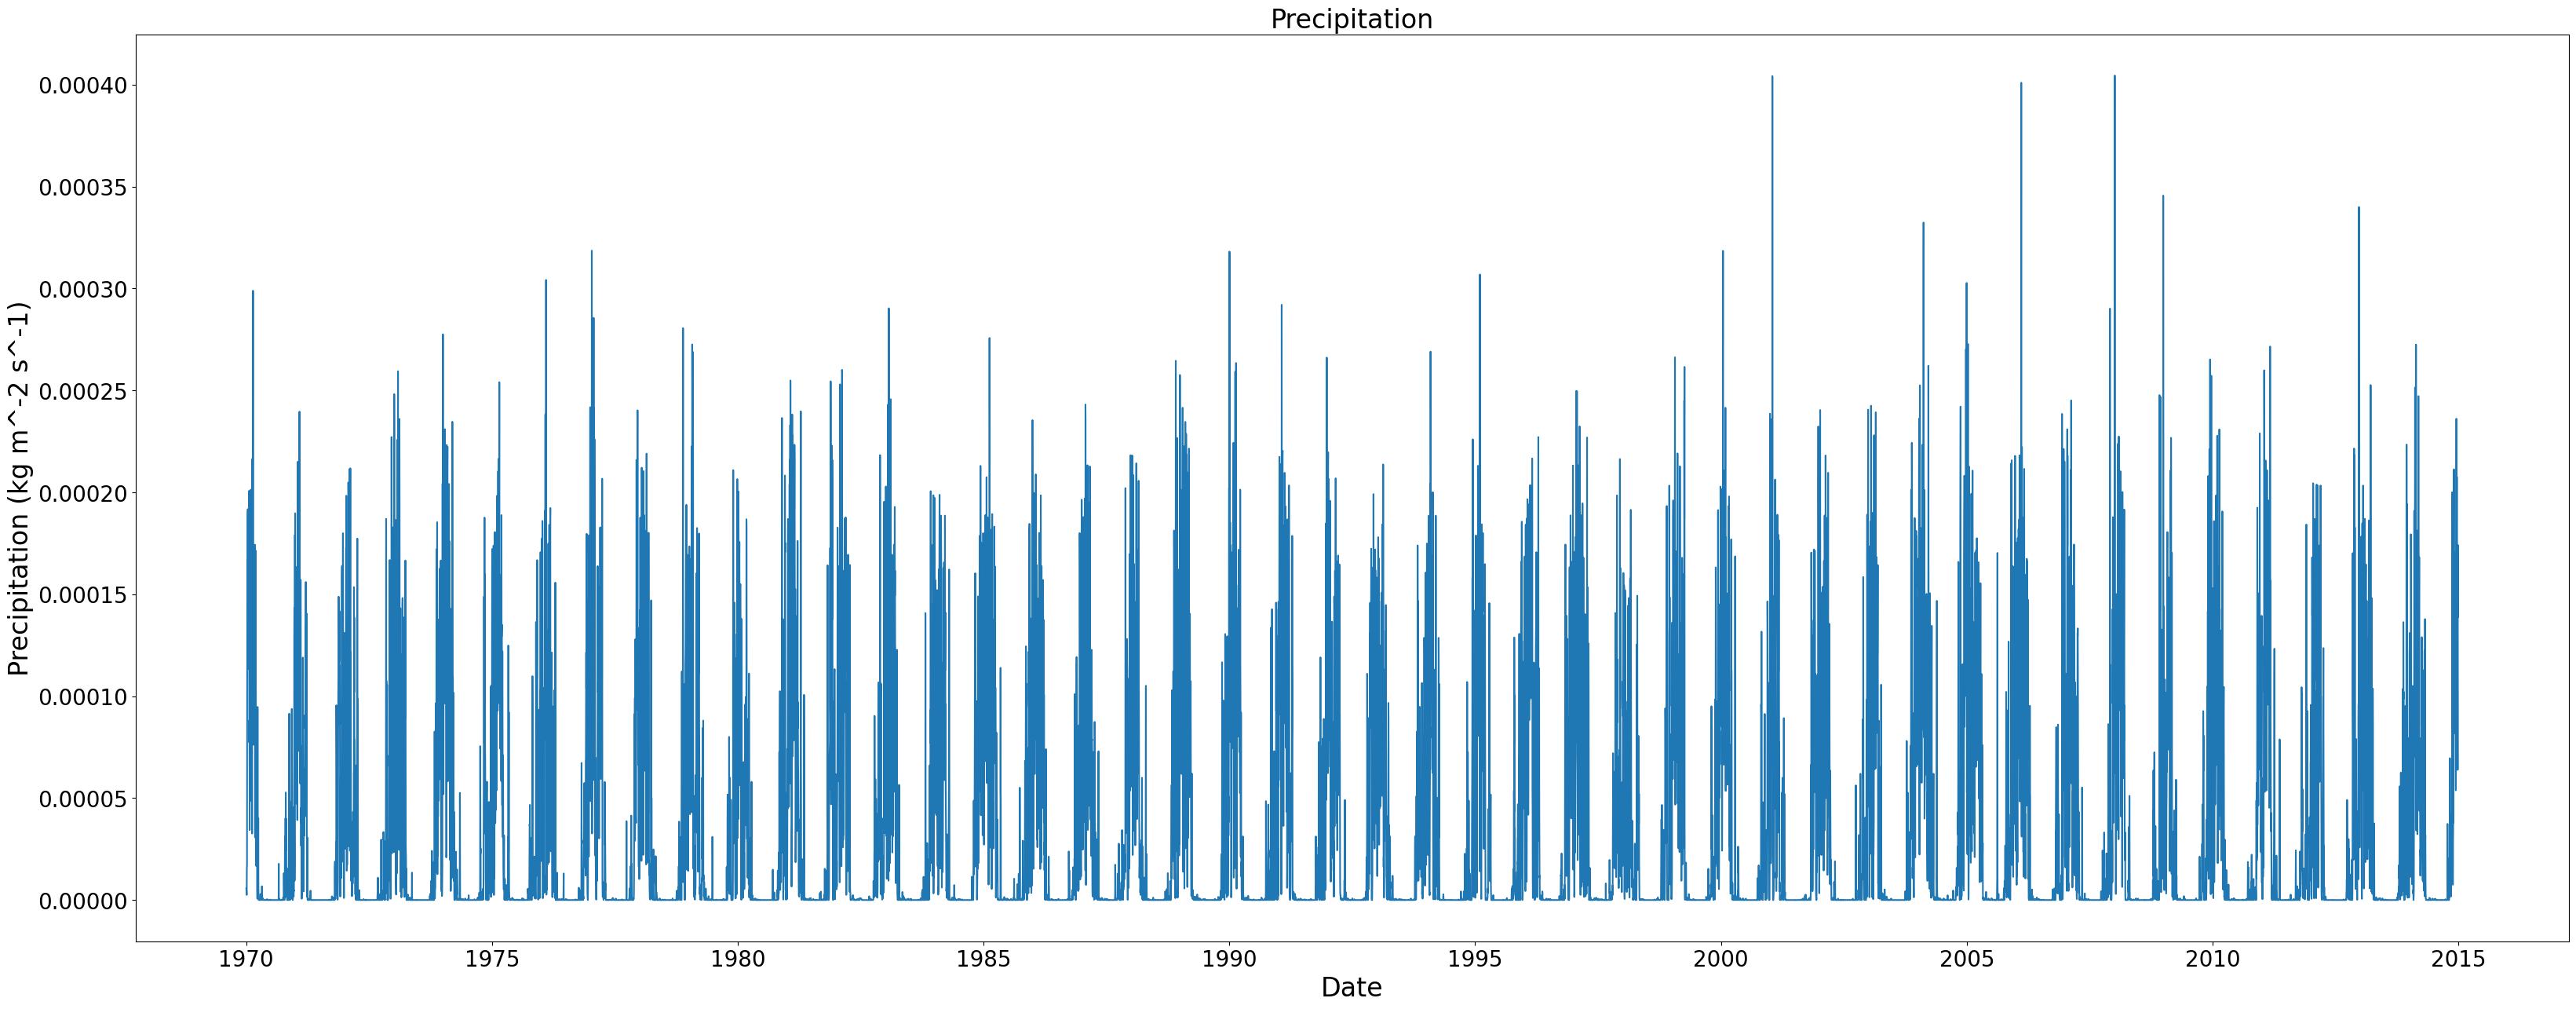

In [8]:
fig, ax = plt.subplots(figsize=(40, 15))
pr['pr'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Precipitation (kg m^-2 s^-1)", fontsize=24)
plt.title("Precipitation", fontsize=24);

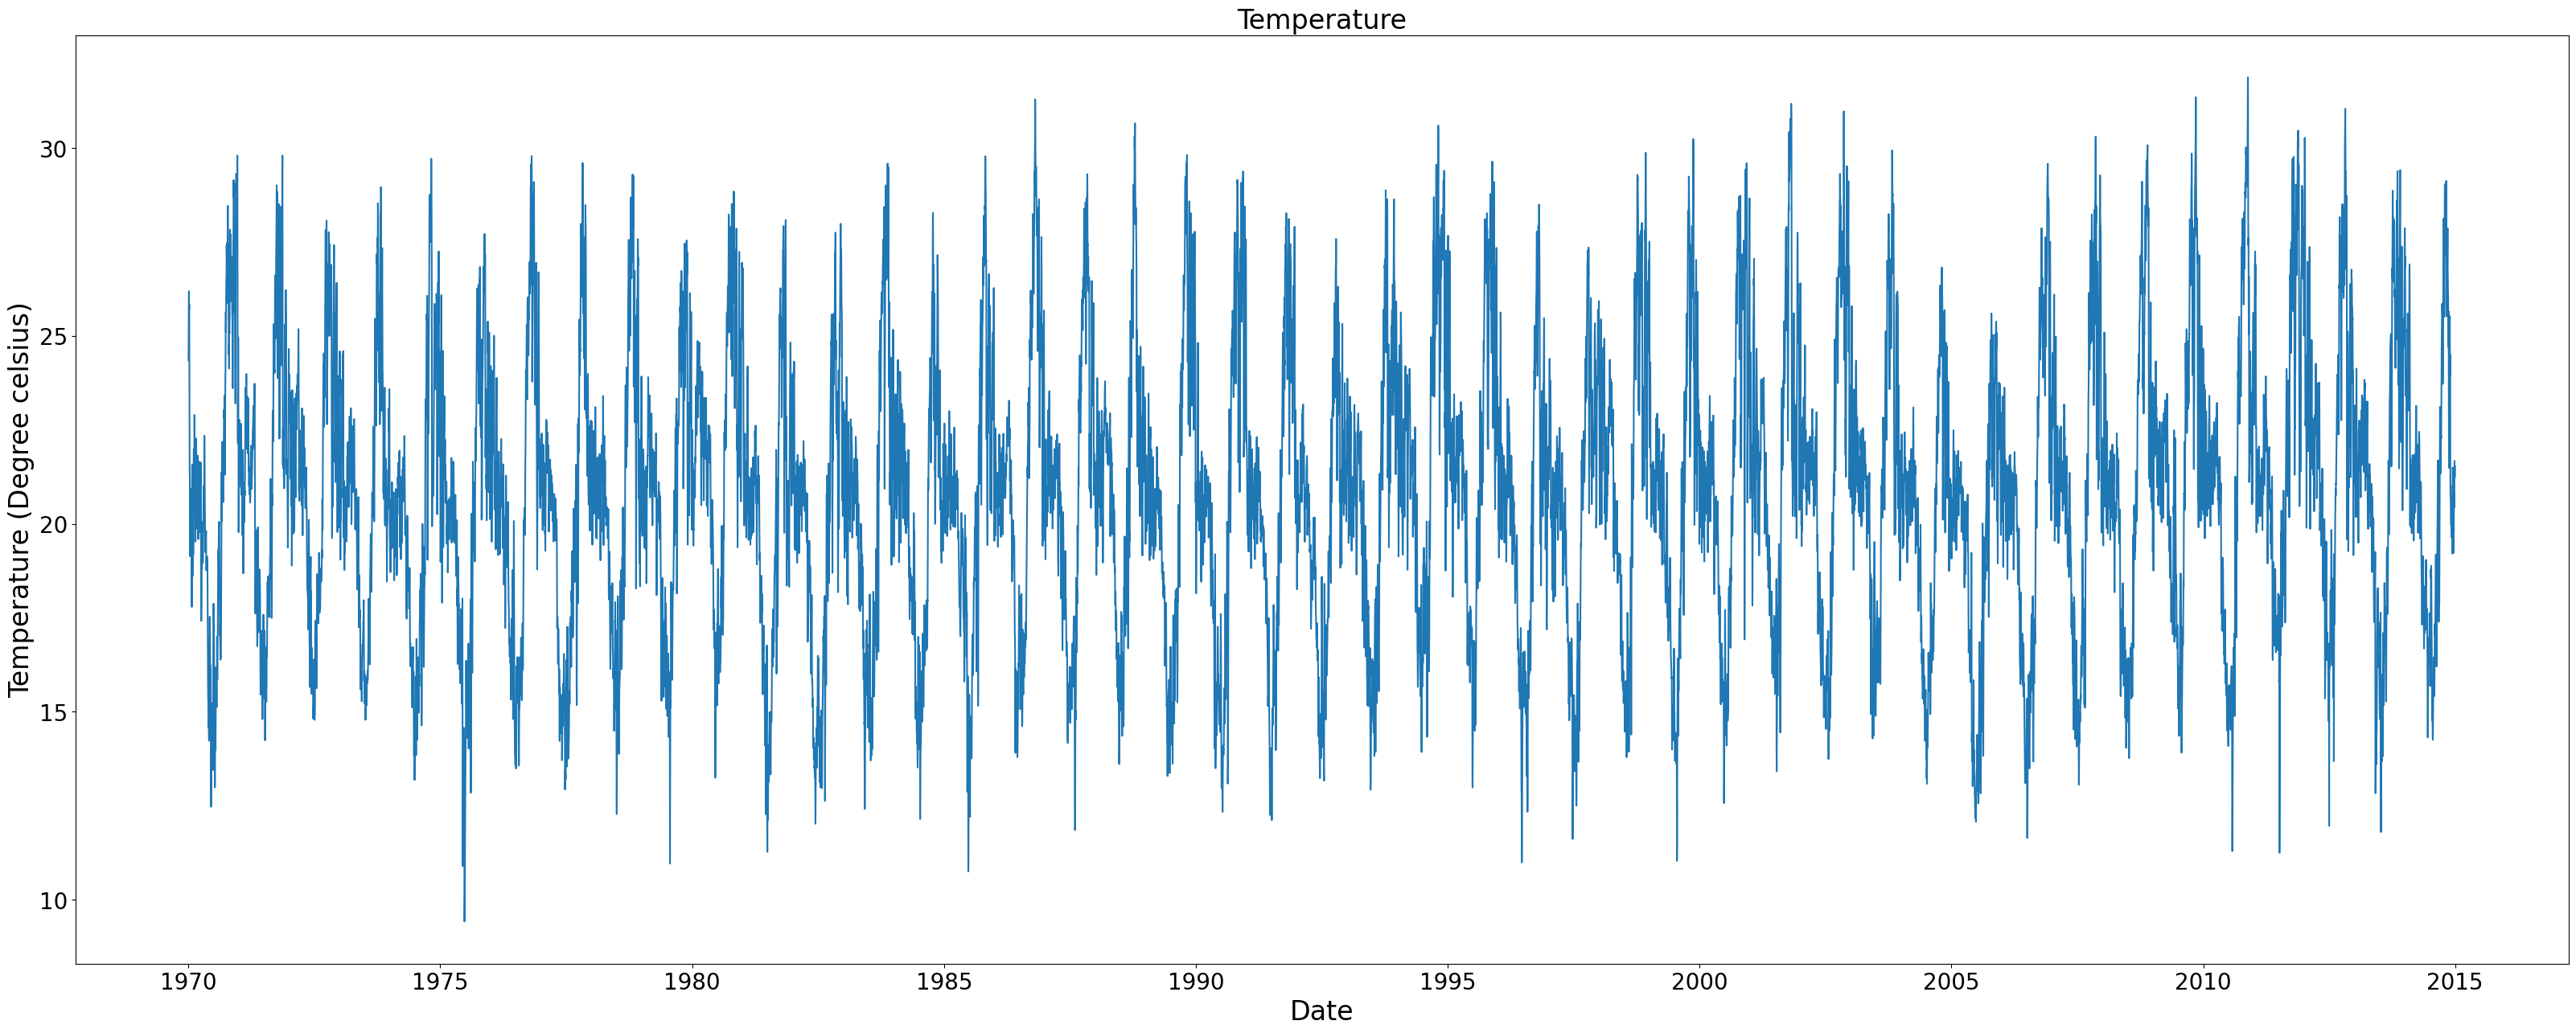

In [9]:
tas['tas'] = tas['tas'] - 273.15

fig, ax = plt.subplots(figsize=(40, 15))
tas['tas'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Temperature (Degree celsius)", fontsize=24)
plt.title("Temperature", fontsize=24);

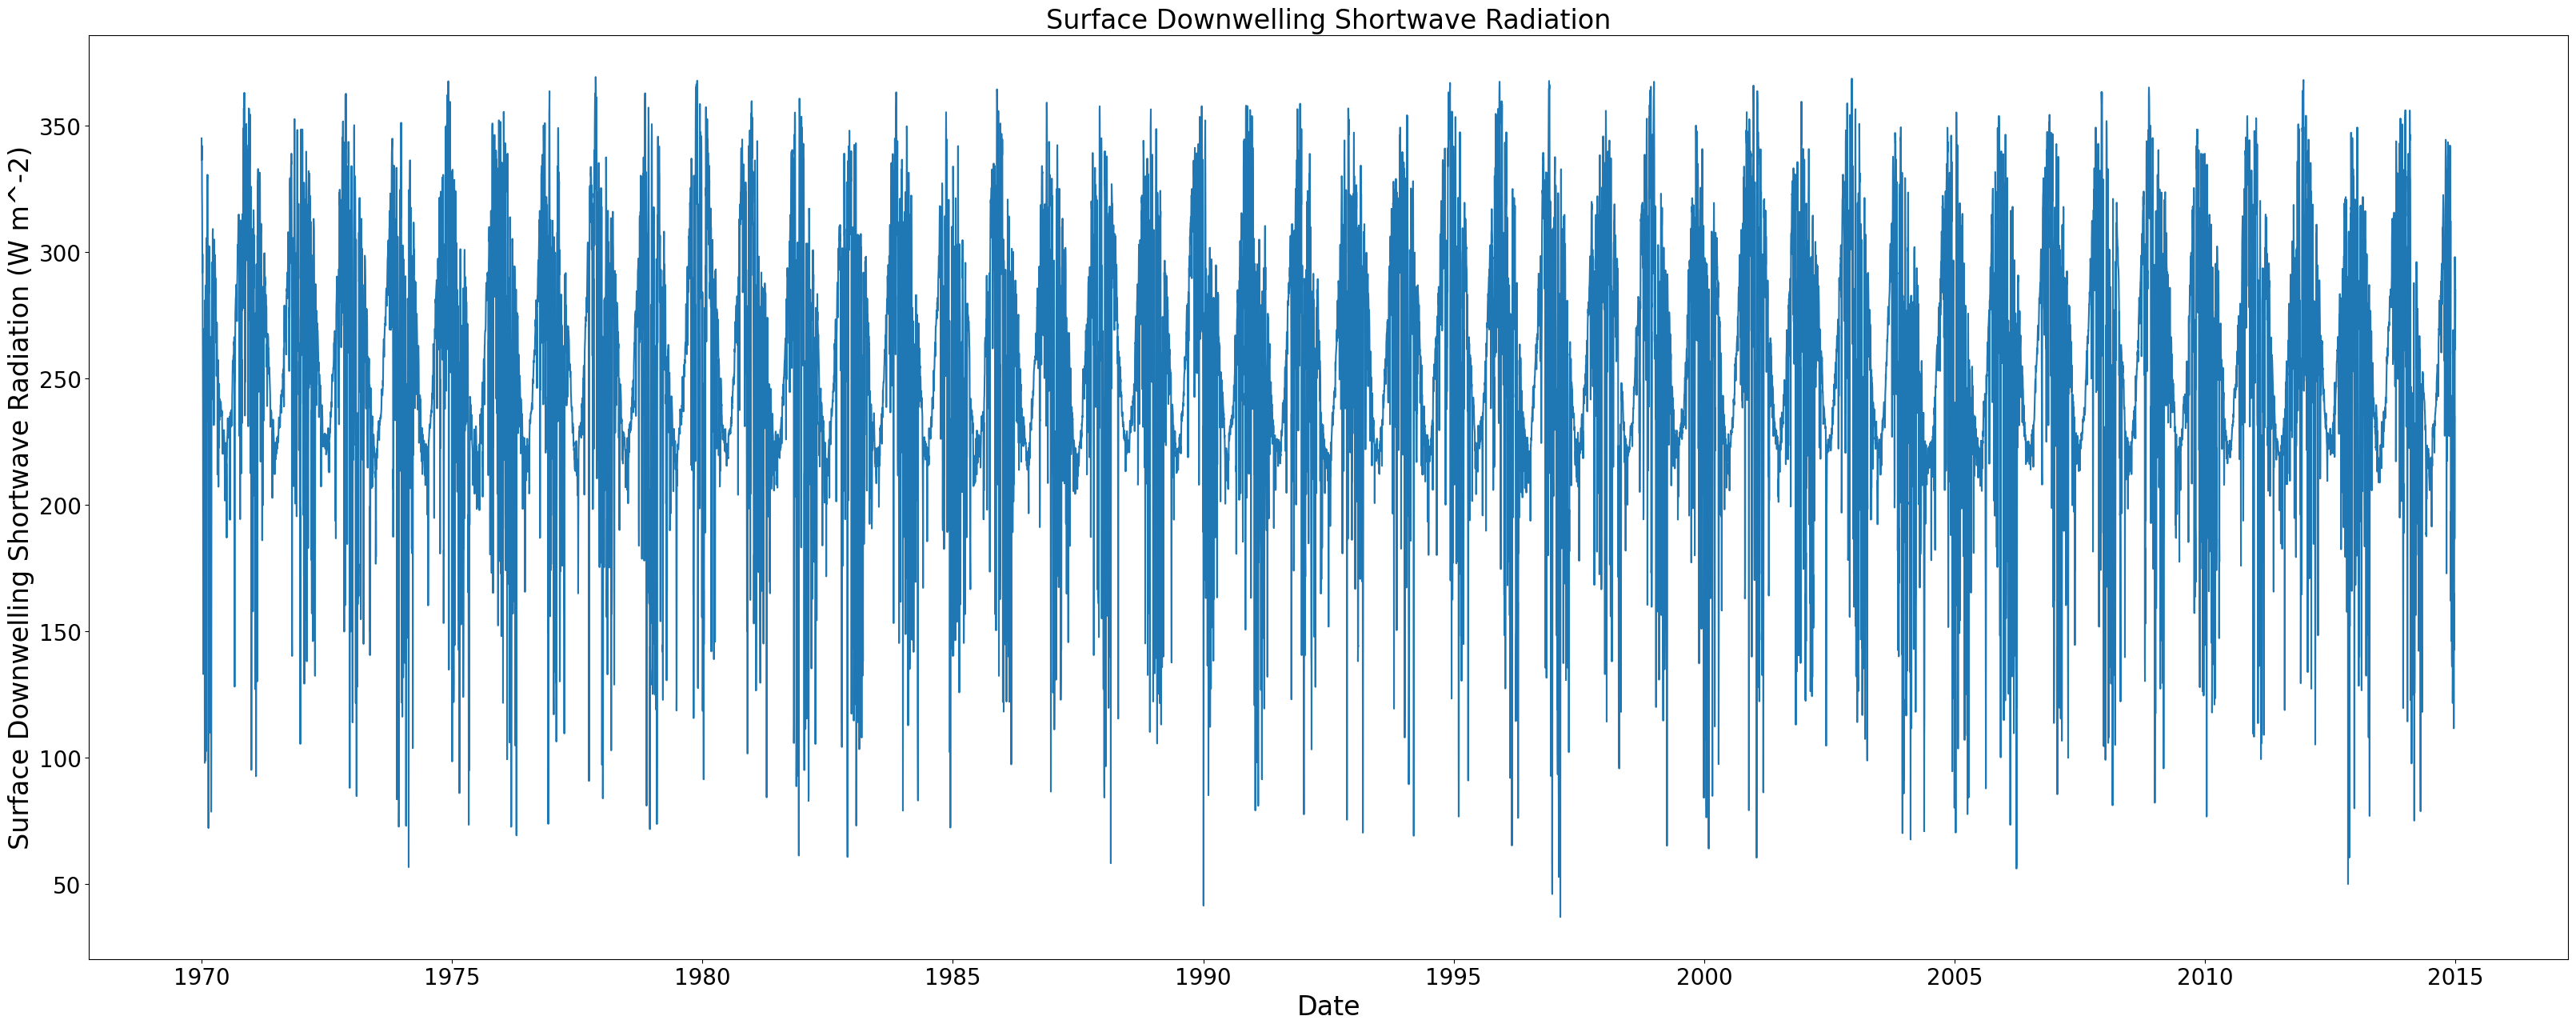

In [10]:
fig, ax = plt.subplots(figsize=(40, 15))
rsds['rsds'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Surface Downwelling Shortwave Radiation (W m^-2)", fontsize=24)
plt.title("Surface Downwelling Shortwave Radiation", fontsize=24);

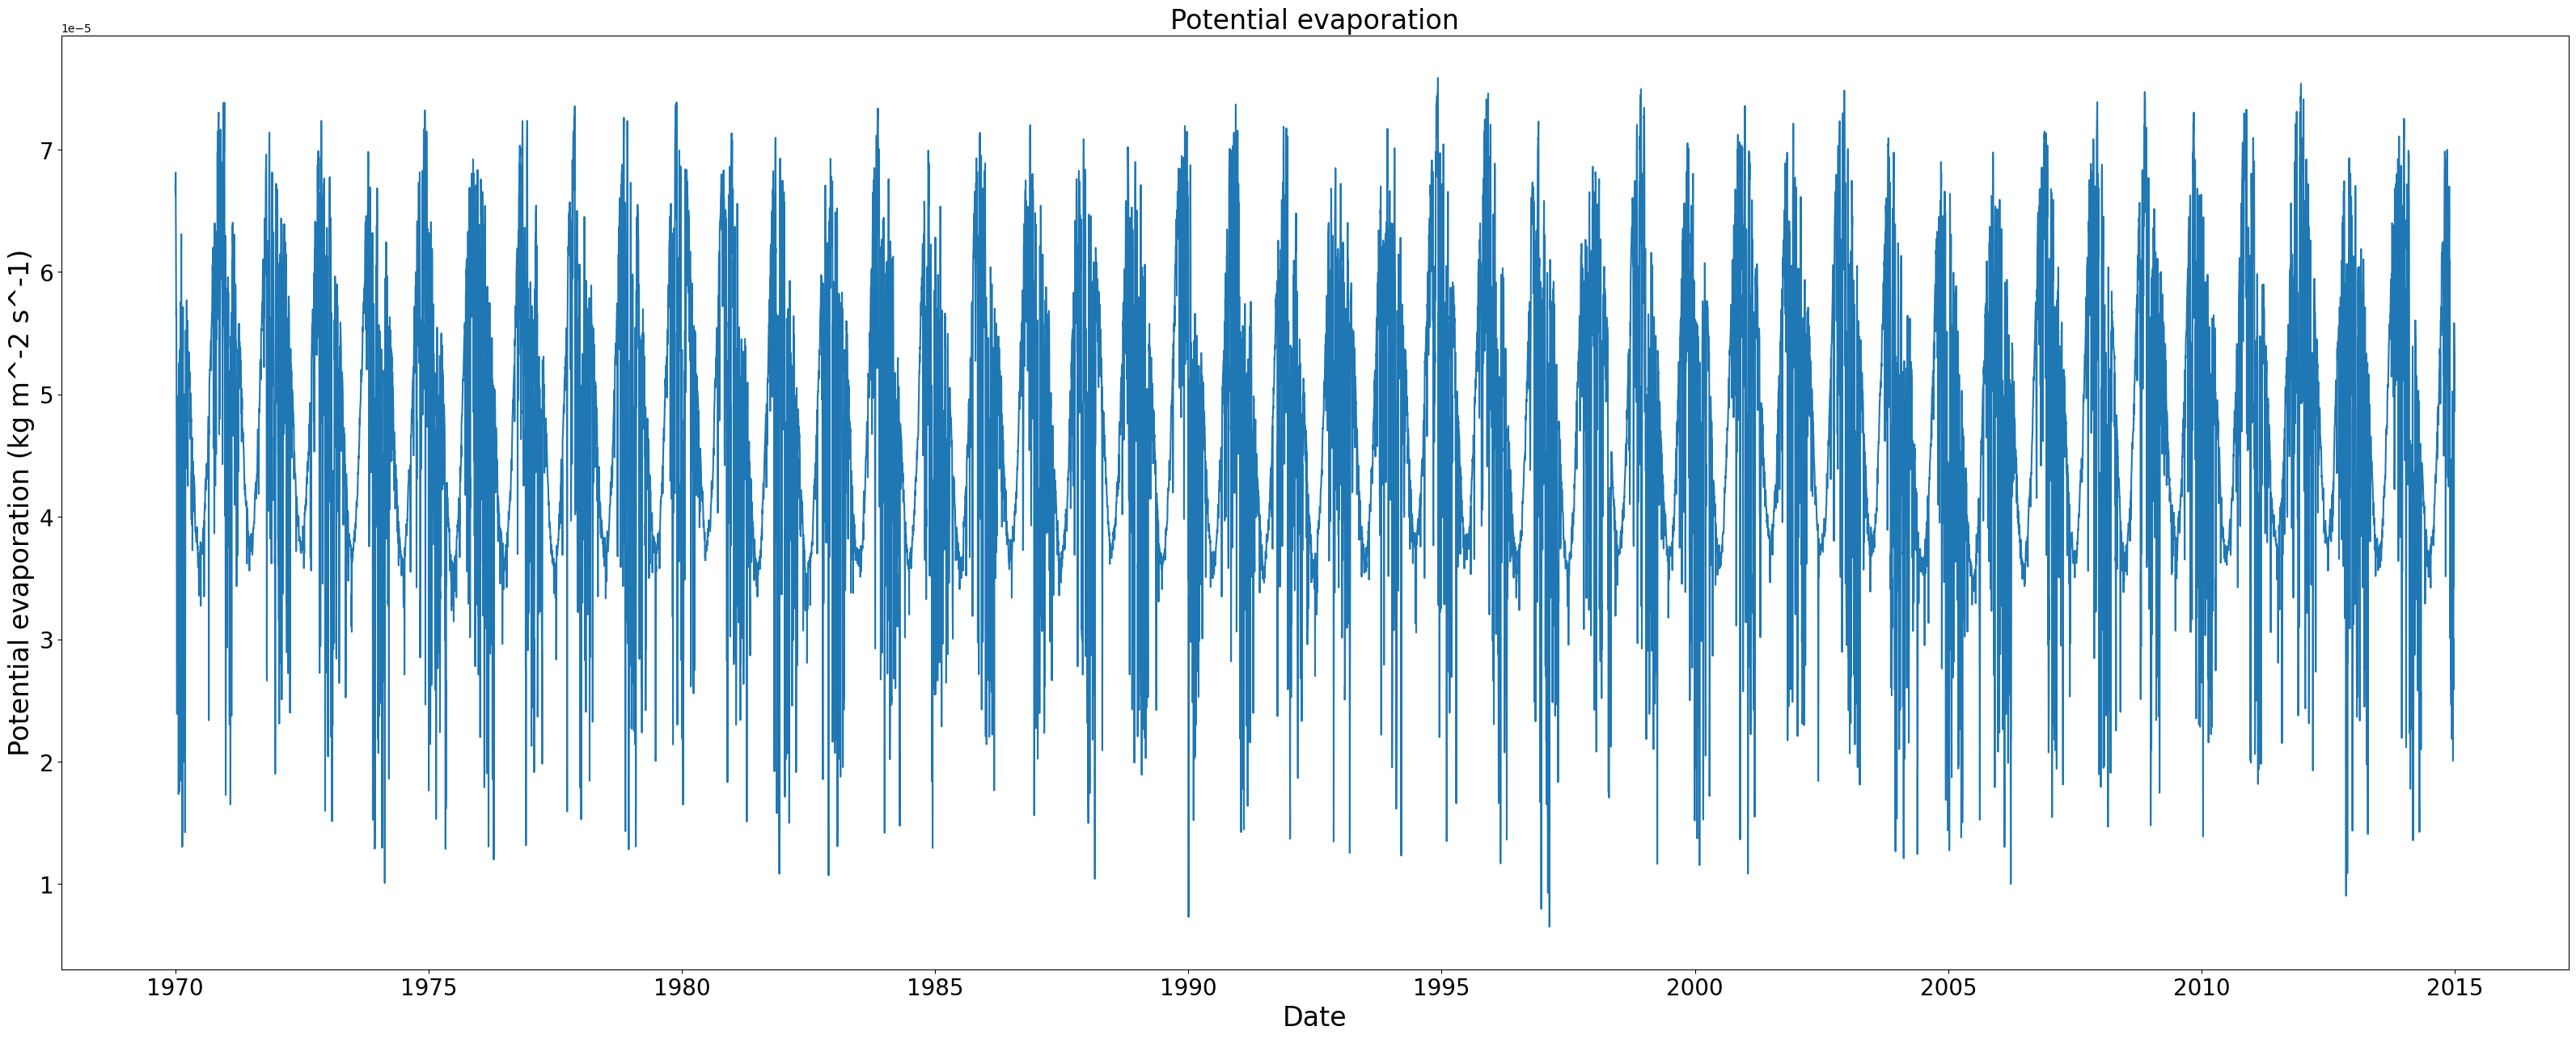

In [11]:
fig, ax = plt.subplots(figsize=(40, 15))
evspsblpot['evspsblpot'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Potential evaporation (kg m^-2 s^-1)", fontsize=24)
plt.title("Potential evaporation", fontsize=24);

In [12]:
data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2015, 2016, 2017, 2018, 2019, 2020, 2021])]

In [13]:
Area_km2 = 173696.852

def mmday_to_m3s(Q_sim_mmday, area_km2):
    return (Q_sim_mmday * area_km2) / 86.4

In [14]:
par_0 = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
       3.72295856e-01]

param_names = ["Imax",
               "Ce",
               "Sumax",
               "Beta",
               "Pmax",
               "Tlag",
               "Kf",
               "Ks",
               "FM"
               ]

print(list(zip(param_names, par_0)))

[
    ('Imax', 7.00392414),
    ('Ce', 0.41228299),
    ('Sumax', 2248.93758),
    ('Beta', 2.73819672),
    ('Pmax', 0.184946158),
    ('Tlag', 22.4829623),
    ('Kf', 0.0149246751),
    ('Ks', 0.000655485347),
    ('FM', 0.372295856)
]

In [15]:
s_0 = np.array([0,  100,  0,  5,  0])

In [16]:
model = ewatercycle.models.HBV(forcing=historical_CMIP_forcing)

In [17]:
config_file, _ = model.setup(parameters=par_0, initial_storage=s_0)

In [18]:
model.initialize(config_file)

In [19]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [20]:
model.finalize()

In [21]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

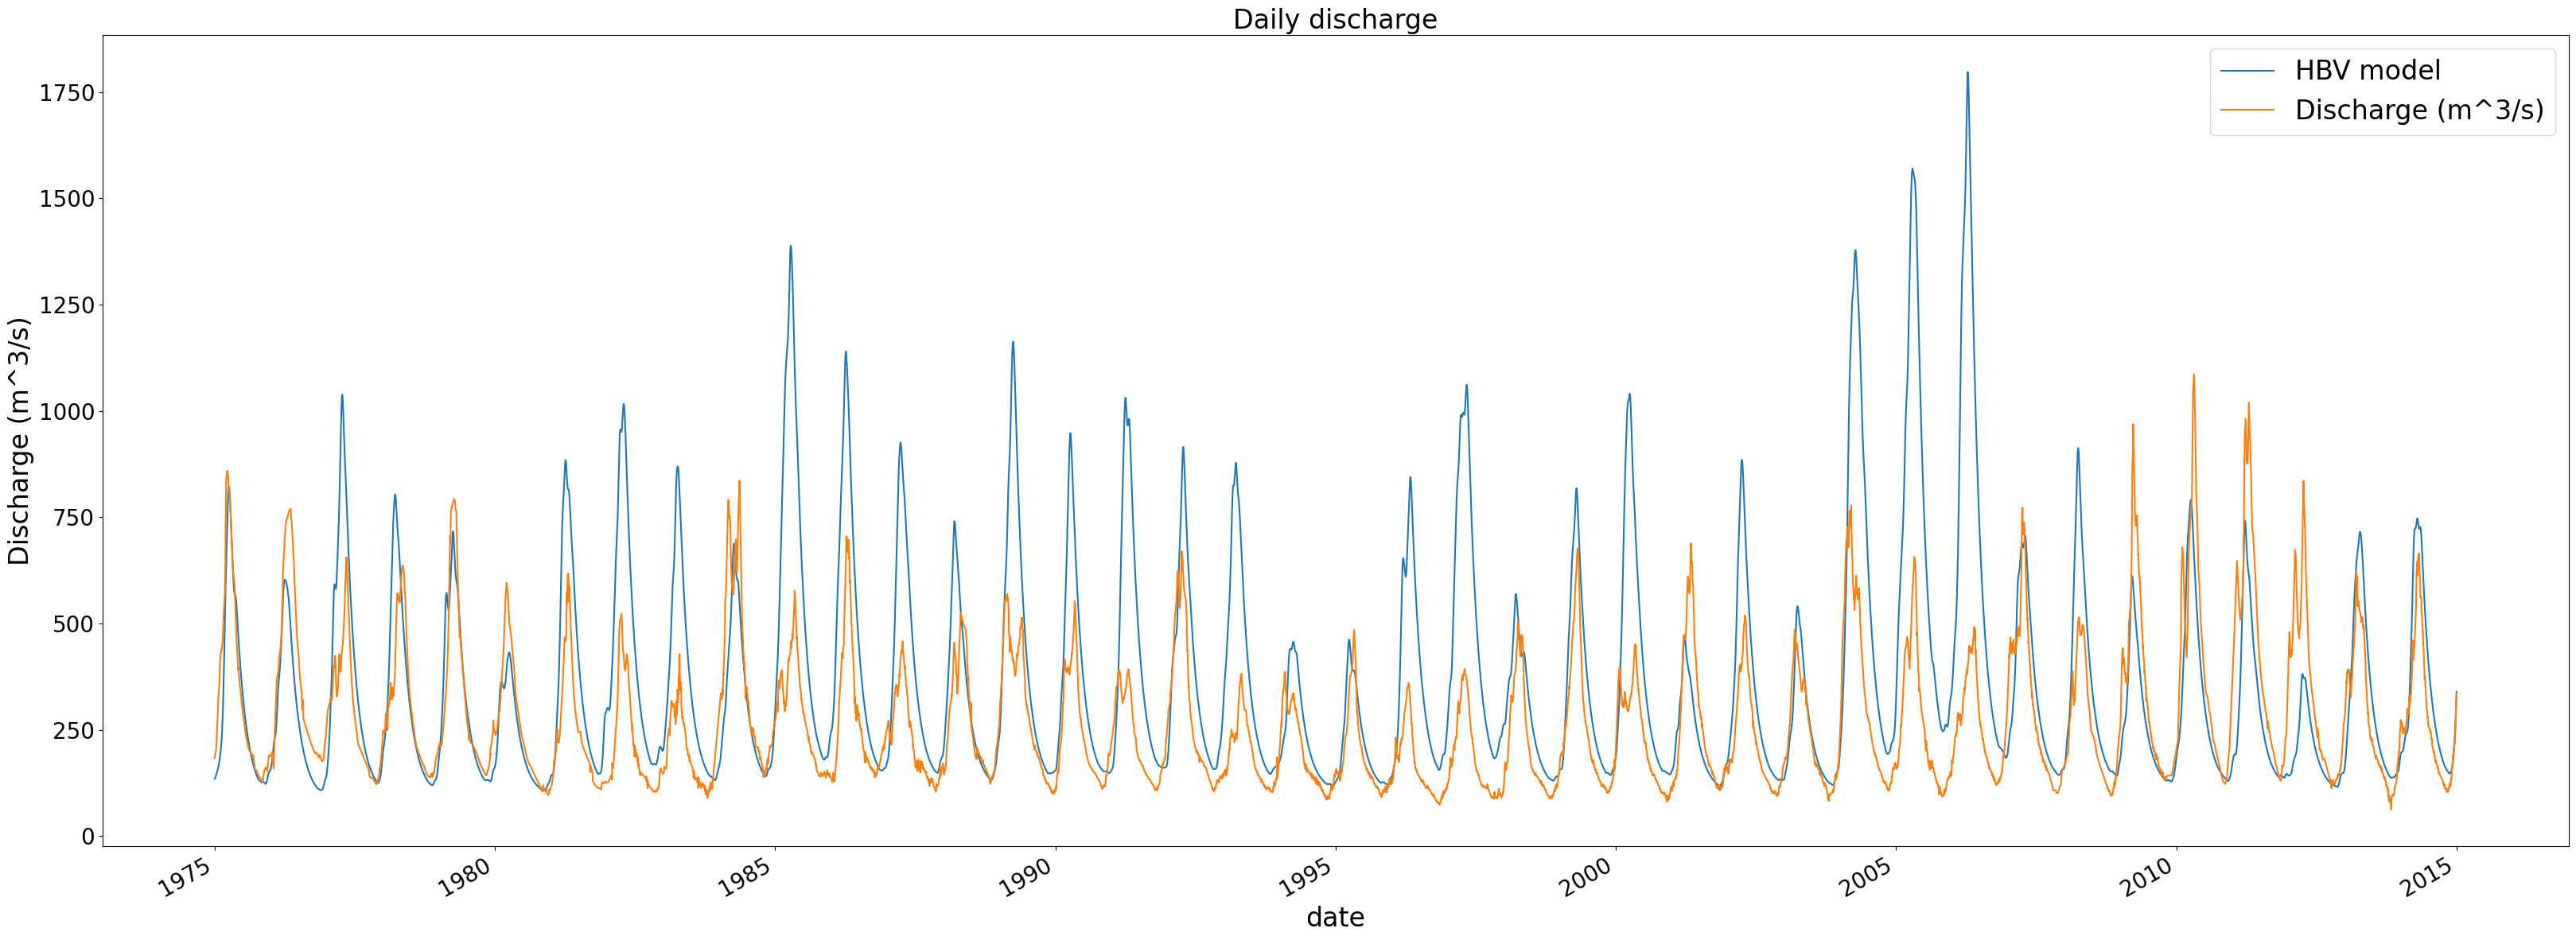

In [28]:
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd['1975'::].plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24);

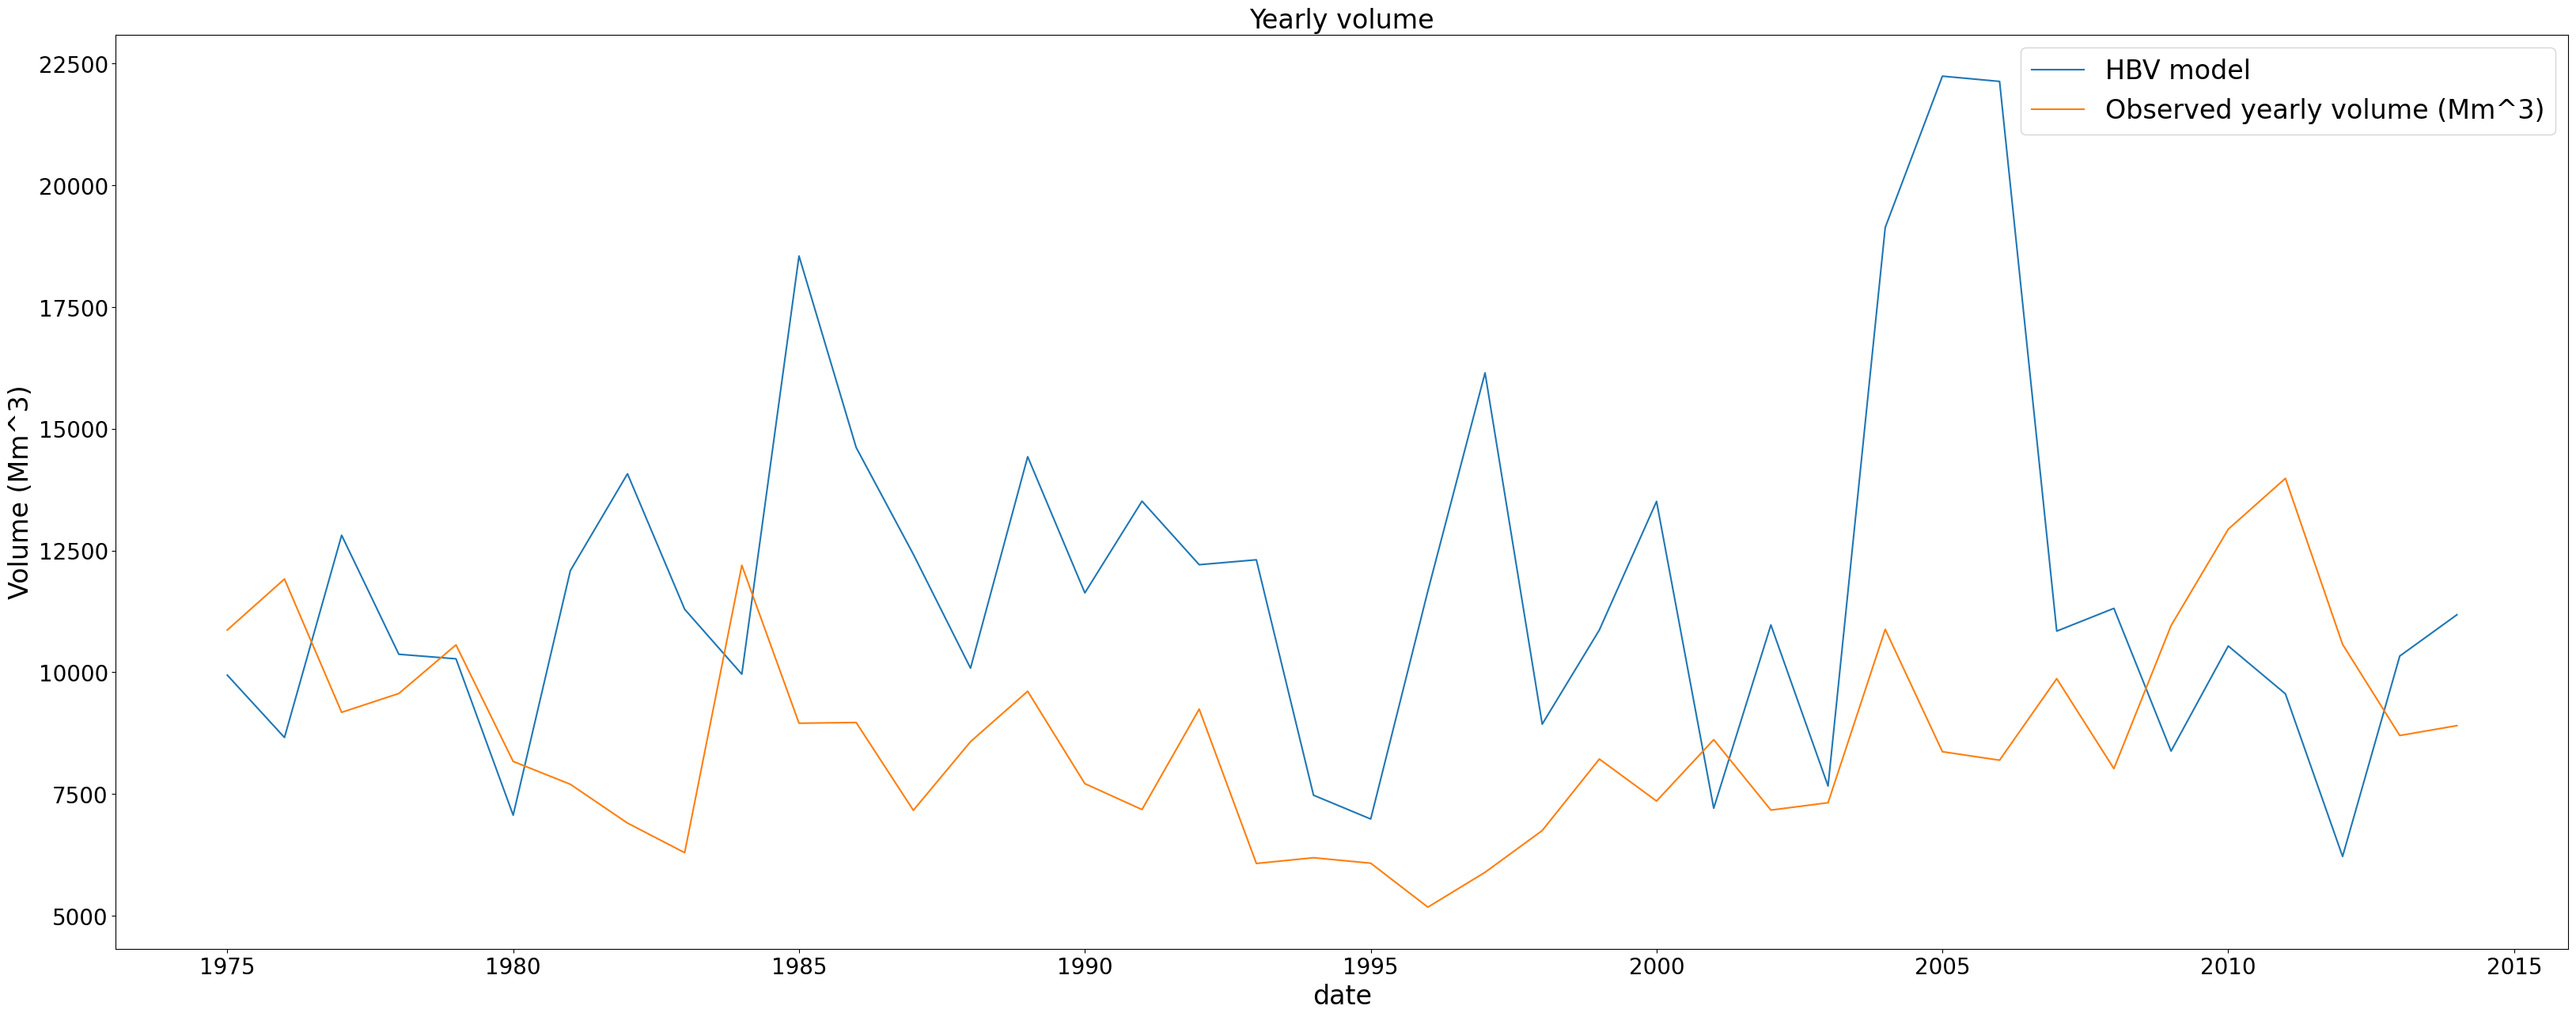

In [43]:
yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.index = yearly_volume.index.year
yearly_volume.columns = ['Observed yearly volume (Mm^3)']

Q_model_pd = Q_model_pd[~Q_model_pd.index.year.isin([1970, 1971, 1972, 1973, 1974])]
CMIP_yearly_volume = (Q_model_pd * 3600 * 24).resample('YE').sum() / 1e6
CMIP_yearly_volume.index = CMIP_yearly_volume.index.year
CMIP_yearly_volume.columns = ['Modelled yearly volume (Mm^3)']

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Volume (Mm^3)", fontsize=24)
CMIP_yearly_volume.plot(ax=ax)
yearly_volume.plot(ax=ax)
plt.legend(fontsize=24)
plt.title('Yearly volume', fontsize=24);

In [71]:
CMIP_yearly_volume_sorted = np.sort(CMIP_yearly_volume)[::-1]

def power_law(x, a, b):
    return a * x ** b

def calculate_return_periods(sorted_model_data):
    n = len(sorted_model_data)
    rank = np.arange(1, n + 1)
    return_periods_years = (n + 1) / rank

    return_periods_years_subset = return_periods_years[return_periods_years >= 0]
    sorted_data_subset = sorted_model_data[return_periods_years >= 0]

    params, _ = curve_fit(power_law, return_periods_years_subset, sorted_data_subset)
    a_opt, b_opt = params

    x_fit = np.logspace(0, np.log(max(return_periods_years_subset)), 1000)
    y_fit = power_law(x_fit, a_opt, b_opt)
    return x_fit, y_fit, a_opt, b_opt, return_periods_years_subset, sorted_data_subset

x_fit, y_fit, a_opt, b_opt, return_periods_years_subset, sorted_data_subset = calculate_return_periods(CMIP_yearly_volume_sorted)

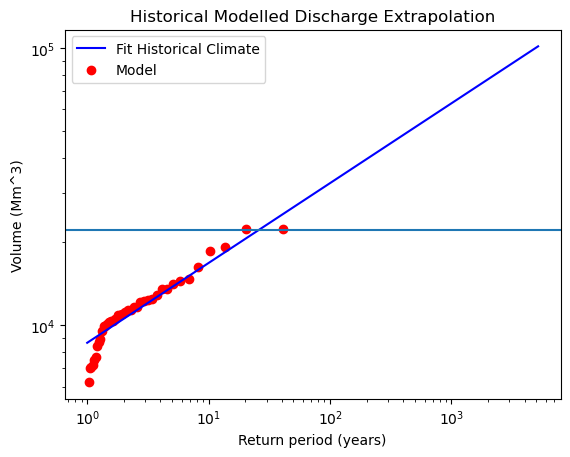

In [80]:
plt.plot(x_fit, y_fit, color='blue', label=f'Fit Historical Climate')
plt.xscale('log')
plt.yscale('log')

plt.scatter(return_periods_years_subset, sorted_data_subset, label='Model', color='red')
plt.legend()
plt.xlabel('Return period (years)')
plt.ylabel('Volume (Mm^3)')
plt.title('Historical Modelled Discharge Extrapolation')

plt.axhline(y=22000)